Modeling rows: 60113
Train breach rate: 0.333  | Test breach rate: 0.333

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.79      0.82      0.81      8025
           1       0.61      0.57      0.59      3998

    accuracy                           0.74     12023
   macro avg       0.70      0.70      0.70     12023
weighted avg       0.73      0.74      0.74     12023

ROC-AUC: 0.756

--- Random Forest (unweighted) ---
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      8025
           1       0.66      0.59      0.62      3998

    accuracy                           0.76     12023
   macro avg       0.73      0.72      0.73     12023
weighted avg       0.76      0.76      0.76     12023

ROC-AUC: 0.776

--- Random Forest (class_weight='balanced') ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      8025
           1       0

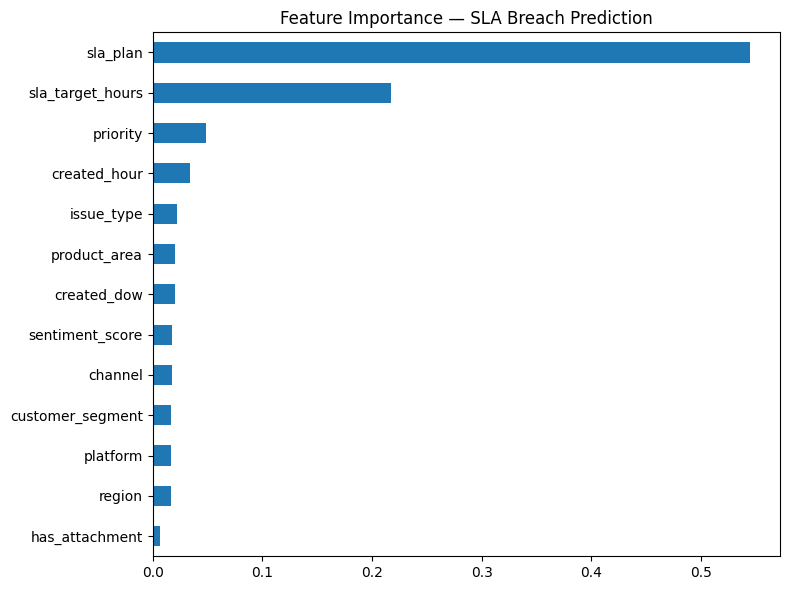

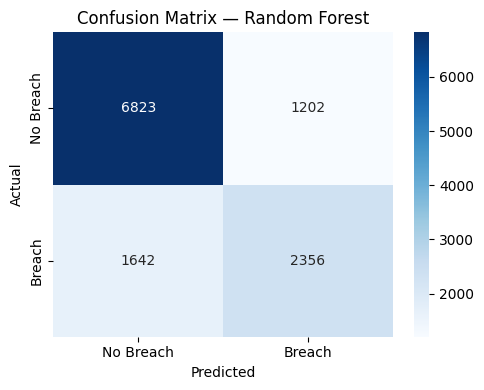


Model saved to Models/sla_breach_model.pkl


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('../Dataset/Cleaned/support_tickets_cleaned.csv')
df['created_at'] = pd.to_datetime(df['created_at'])

# --- 1. Filter to terminal tickets (breach is only defined here) ---
model_df = df[df['is_terminal'] == True].copy()
print("Modeling rows:", model_df.shape[0])

# --- 2. Feature selection: ONLY creation-time-known fields ---
features = [
    'priority', 'sla_plan', 'sla_target_hours', 'product_area', 'issue_type',
    'channel', 'customer_segment', 'region', 'platform',
    'has_attachment', 'sentiment_score', 'created_hour', 'created_dow'
]
target = 'sla_breached'

X = model_df[features].copy()
y = model_df[target].astype(int)

# --- 3. Encode categoricals ---
cat_features = ['priority', 'sla_plan', 'product_area', 'issue_type',
                 'channel', 'customer_segment', 'region', 'platform', 'created_dow']
encoders = {}
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# --- 4. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train breach rate:", y_train.mean().round(3), " | Test breach rate:", y_test.mean().round(3))

# --- 5. Baseline: Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
print("\n--- Logistic Regression ---")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 3))

# --- 6. Random Forest (no class_weight first) ---
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
print("\n--- Random Forest (unweighted) ---")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 3))

# --- 7. Random Forest with class_weight='balanced' for comparison ---
rf_bal = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_bal.fit(X_train, y_train)
rf_bal_pred = rf_bal.predict(X_test)
rf_bal_proba = rf_bal.predict_proba(X_test)[:, 1]
print("\n--- Random Forest (class_weight='balanced') ---")
print(classification_report(y_test, rf_bal_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_bal_proba), 3))

# --- 8. Feature importance (best model — pick after comparing above) ---
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importances:\n", importances)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance — SLA Breach Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../Images/Model/feature_importance.png')
plt.show()

# --- 9. Confusion matrix for chosen model ---
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Breach', 'Breach'], yticklabels=['No Breach', 'Breach'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../Images/Model/confusion_matrix.png')
plt.show()

# --- 10. Save model + encoders ---
joblib.dump(rf, '../Models/sla_breach_model.pkl')
joblib.dump(encoders, '../Models/label_encoders.pkl')
print("\nModel saved to Models/sla_breach_model.pkl")

In [2]:
# Overwrite saved model with the balanced version (chosen model)
joblib.dump(rf_bal, '../Models/sla_breach_model.pkl')
print("Final model (class_weight='balanced') saved to Models/sla_breach_model.pkl")

# --- Generate predictions output ---
predictions_df = model_df.loc[X_test.index, ['ticket_id', 'priority', 'sla_plan', 'created_at']].copy()
predictions_df['actual_breach'] = y_test.values
predictions_df['predicted_breach'] = rf_bal_pred
predictions_df['breach_probability'] = rf_bal_proba.round(3)
predictions_df.to_csv('../Outputs/Predictions/sla_breach_predictions.csv', index=False)
print("Saved predictions:", predictions_df.shape)
predictions_df.head()

Final model (class_weight='balanced') saved to Models/sla_breach_model.pkl
Saved predictions: (12023, 7)


,ticket_id,priority,sla_plan,created_at,actual_breach,predicted_breach,breach_probability
88234,TCKT_088235,high,gold,2025-10-15 23:19:58,1,1,0.724
85004,TCKT_085005,medium,gold,2025-08-19 23:14:52,0,1,0.775
72553,TCKT_072554,low,standard,2024-01-18 22:47:31,0,0,0.283
3802,TCKT_003803,medium,gold,2024-02-15 20:33:21,1,1,0.752
96211,TCKT_096212,medium,standard,2023-09-02 22:08:07,1,0,0.280
